## d'Alembert system: Monte Carlo parameter sweep
Runs batches of simulated betting sessions with random wager sizes and counts, computes ROI, bust and profit rates, and logs each batch to `monteCarlo.csv`.

In [1]:
# Efficient Monte Carlo simulation for dAlembert system
import random
import matplotlib.pyplot as plt
import csv

sampleSize = 100  # Reduced for efficiency
startingFunds = 10000

def rollDice():
    return random.randint(1, 100) > 50

def dAlembert(funds, initial_wager, wager_count):
    value = funds
    wager = initial_wager
    currentWager = 1
    previousWager = 'win'
    previousWagerAmount = initial_wager
    while currentWager <= int(wager_count):
        if previousWager == 'win':
            if wager != initial_wager:
                wager = max(wager - initial_wager, 1)
            if rollDice():
                value += wager
                previousWagerAmount = wager
            else:
                value -= wager
                previousWager = 'loss'
                previousWagerAmount = wager
                if value <= 0:
                    return 0, False
        elif previousWager == 'loss':
            wager = previousWagerAmount + initial_wager
            if (value - wager) <= 0:
                wager = value
            if rollDice():
                value += wager
                previousWagerAmount = wager
                previousWager = 'win'
            else:
                value -= wager
                previousWagerAmount = wager
                if value <= 0:
                    return 0, False
        currentWager += 1
    return value, value > funds

# Efficient simulation loop
num_simulations = 5
results = []
for sim in range(num_simulations):
    wagerSize = random.uniform(1.0, 1000.0)
    wagerCount = random.uniform(10.0, 1000.0)
    Ret = 0.0
    da_profits = 0.0
    da_busts = 0.0
    daSampSize = 100  # Reduced for speed
    for _ in range(daSampSize):
        final_value, profit = dAlembert(startingFunds, wagerSize, wagerCount)
        Ret += final_value
        if profit:
            da_profits += 1
        elif final_value == 0:
            da_busts += 1
    ROI = Ret - (daSampSize * startingFunds)
    totalInvested = daSampSize * startingFunds
    percentROI = (ROI / totalInvested) * 100.0
    wagerSizePercent = (wagerSize / startingFunds) * 100.0
    color = 'g' if percentROI > 1 else ('r' if percentROI < -1 else 'b')
    results.append((percentROI, wagerSizePercent, wagerCount, color))
    # Save to CSV
    with open('monteCarlo.csv', 'a') as saveFile:
        saveLine = f"\n{percentROI},{wagerSizePercent},{wagerCount},{color}"
        saveFile.write(saveLine)
print("Simulations complete. Results saved to monteCarlo.csv.")

Simulations complete. Results saved to monteCarlo.csv.


## 2D visualisation
Each point is one simulation batch: wager size (% of funds) vs wager count, coloured green (ROI > 1%), red (ROI < -1%) or blue (neutral).

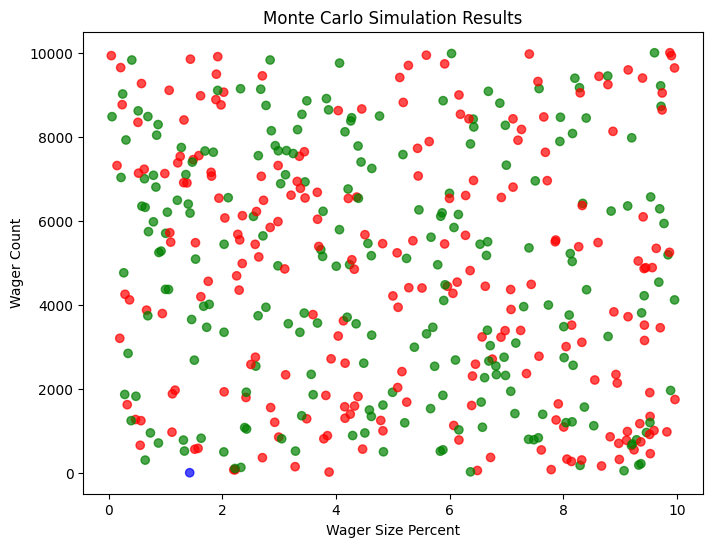

In [2]:
# 2D Scatter Plot for Monte Carlo Results
import matplotlib.pyplot as plt
import csv

def graph():
    xs, ys, cs = [], [], []
    with open('monteCarlo.csv', 'r') as montecarlo:
        datas = csv.reader(montecarlo, delimiter=',')
        for eachLine in datas:
            if len(eachLine) < 4:
                continue
            try:
                wagerSizePercent = float(eachLine[1])
                wagerCount = float(eachLine[2])
                pcolor = eachLine[3].strip() if eachLine[3].strip() in ['g','r','b','c','m','y','k'] else 'b'
                xs.append(wagerSizePercent)
                ys.append(wagerCount)
                cs.append(pcolor)
            except Exception:
                continue
    plt.figure(figsize=(8,6))
    plt.scatter(xs, ys, c=cs, alpha=0.7)
    plt.xlabel('Wager Size Percent')
    plt.ylabel('Wager Count')
    plt.title('Monte Carlo Simulation Results')
    plt.show()

graph()

## 3D visualisation
Adds percent ROI as the third axis for a fuller view of the risk/return surface.

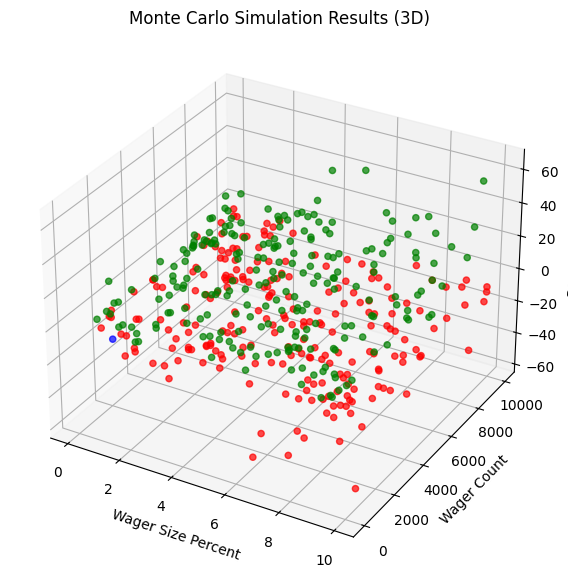

In [3]:
# 3D Plot for more insight
import matplotlib.pyplot as plt
import csv
from mpl_toolkits.mplot3d import Axes3D

def graph3d():
    xs, ys, zs, cs = [], [], [], []
    with open('monteCarlo.csv', 'r') as montecarlo:
        datas = csv.reader(montecarlo, delimiter=',')
        for eachLine in datas:
            if len(eachLine) < 4:
                continue
            try:
                percentROI = float(eachLine[0])
                wagerSizePercent = float(eachLine[1])
                wagerCount = float(eachLine[2])
                pcolor = eachLine[3].strip() if eachLine[3].strip() in ['g','r','b','c','m','y','k'] else 'b'
                xs.append(wagerSizePercent)
                ys.append(wagerCount)
                zs.append(percentROI)
                cs.append(pcolor)
            except Exception:
                continue
    fig = plt.figure(figsize=(10,7))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(xs, ys, zs, c=cs, alpha=0.7)
    ax.set_xlabel('Wager Size Percent')
    ax.set_ylabel('Wager Count')
    ax.set_zlabel('Percent ROI')
    plt.title('Monte Carlo Simulation Results (3D)')
    plt.show()

graph3d()

## Labouchere system
Simulates the Labouchere (cancellation) betting system and tracks funds, wager sizes, wins, losses and bust count.

1000000 997296
Broke Percentage: 10.68


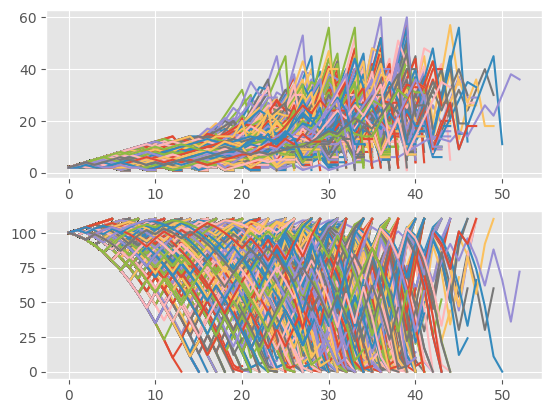

In [4]:
import random
import time
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import style

style.use("ggplot")

broke_count = 0

totalFunded = 0
totalEnding = 0

wins = 0
losses = 0

def Labouchere():
    global broke_count
    global totalFunded
    global totalEnding
    global wins
    global losses

    
    starting_funds = 100

    totalFunded += starting_funds

    
    goal = 10
    system = [1,1,1,1,1,1,1,1,1,1]
    #system = [1,2,2,3,2]

    profit = 0

    current_funds = starting_funds

    wagerSizes = []
    plot_funds = []

    not_broke = True

    wins = 0
    losses = 0

    while profit < goal and not_broke:
        if len(system) > 1:
            size = system[0]+system[-1]
            wagerSizes.append(size)
            plot_funds.append(current_funds)

        else:
            size = system[0]
            wagerSizes.append(size)
            plot_funds.append(current_funds)


        if current_funds <= 0:
            not_broke = False
            broke_count += 1
            losses += 1

        elif current_funds - size <= 0:
            size = current_funds
            not_broke = False
            broke_count += 1

        dice = random.randrange(1,101)

        if dice < 51:
            losses += 1
            system.append(size)
            current_funds -= size
            profit = current_funds - starting_funds

        else:
            wins += 1
            current_funds += size
            profit = current_funds - starting_funds

            if profit != goal:
                try:
                    del system[0]
                    del system[-1]
                except:
                    pass

    wagerSizes.append(size)
    plot_funds.append(current_funds)

    totalEnding += current_funds

    s1.plot(wagerSizes)
    s2.plot(plot_funds)

    


f = plt.figure()
s1 = f.add_subplot(211)
s2 = f.add_subplot(212)

sample_size = 10000

for x in range(sample_size):
    Labouchere()

#print("Winners:",wins,"losers:",losses)
print(totalFunded, totalEnding)
print("Broke Percentage:", ((float(broke_count)/sample_size))*100.0)

plt.show()